Shape: (10000, 14)

Column Names: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   


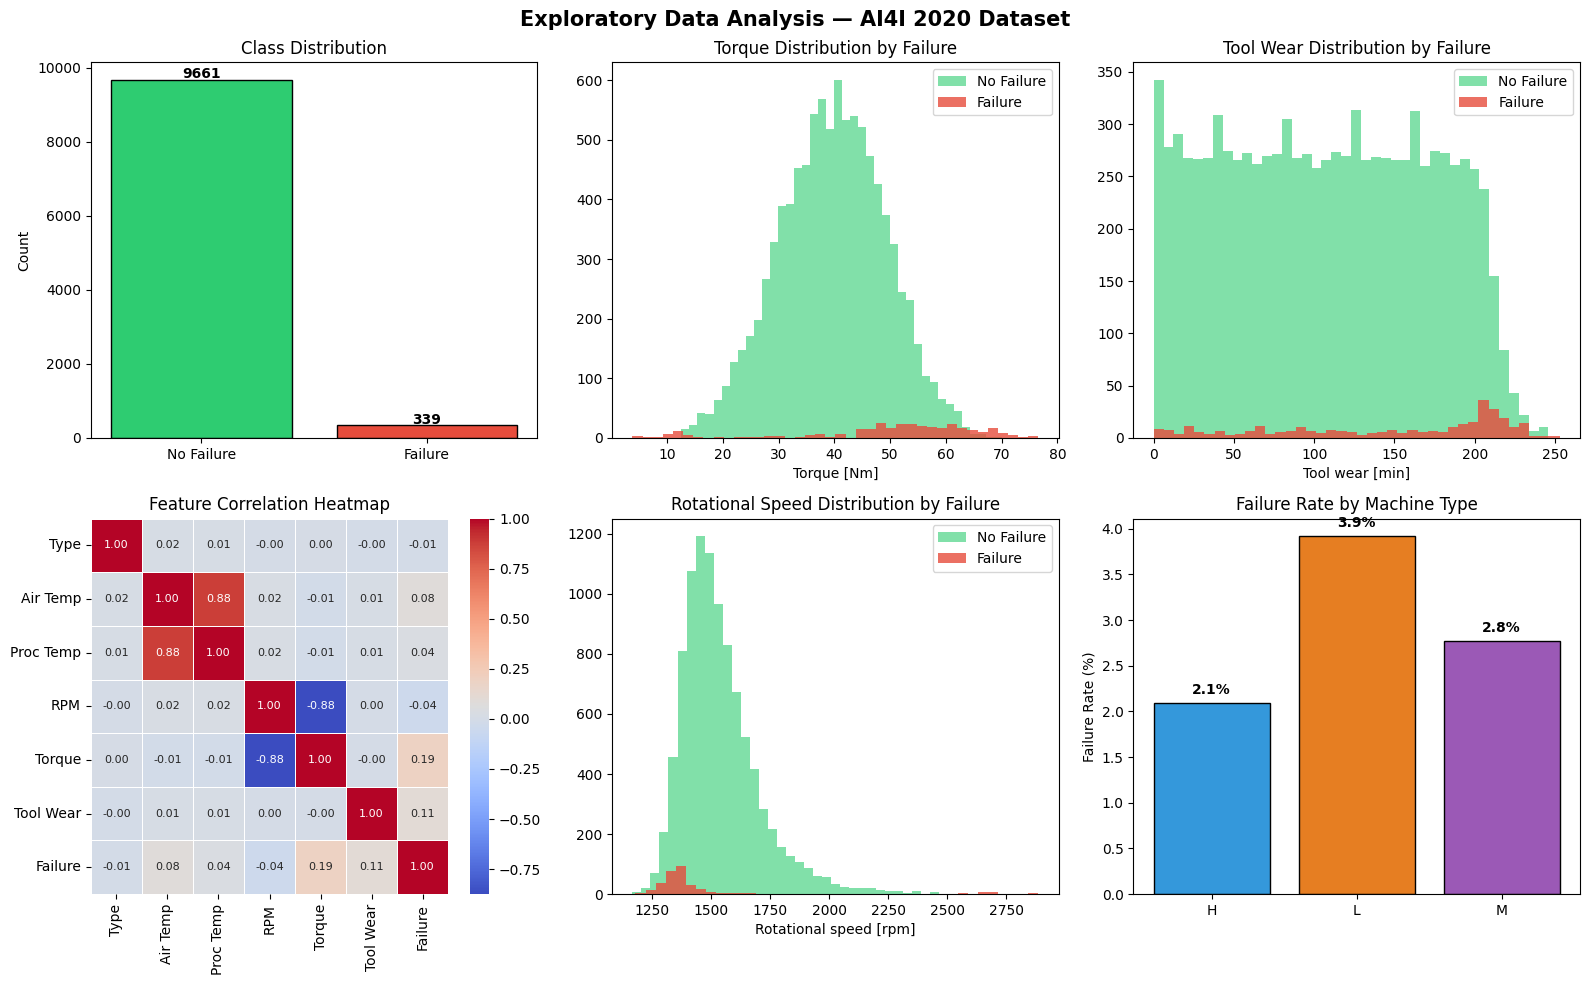

EDA plot saved.

COMPARATIVE RESULTS: RULE-BASED vs ML MODELS
               Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  False Positive Rate
          Rule-Based    0.0815     0.0252  0.6912    0.0487   0.3756               0.1533
 Logistic Regression    0.8210     0.1411  0.8382    0.2415   0.9062               0.0069
       Random Forest    0.9815     0.8974  0.5147    0.6542   0.9678               0.0168
   Gradient Boosting    0.9850     0.8654  0.6618    0.7500   0.9684               0.0118
             XGBoost    0.9845     0.7681  0.7794    0.7737   0.9659               0.0078
Neural Network (MLP)    0.9800     0.7800  0.5735    0.6610   0.9743               0.0149


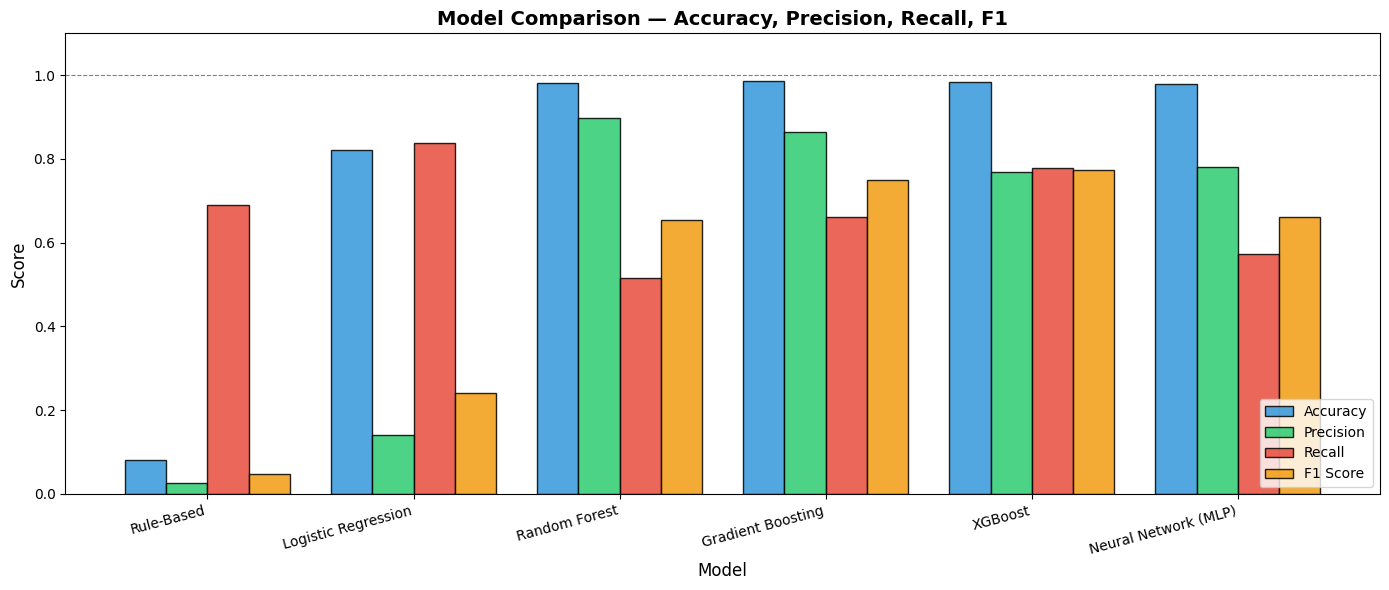

Metrics comparison plot saved.


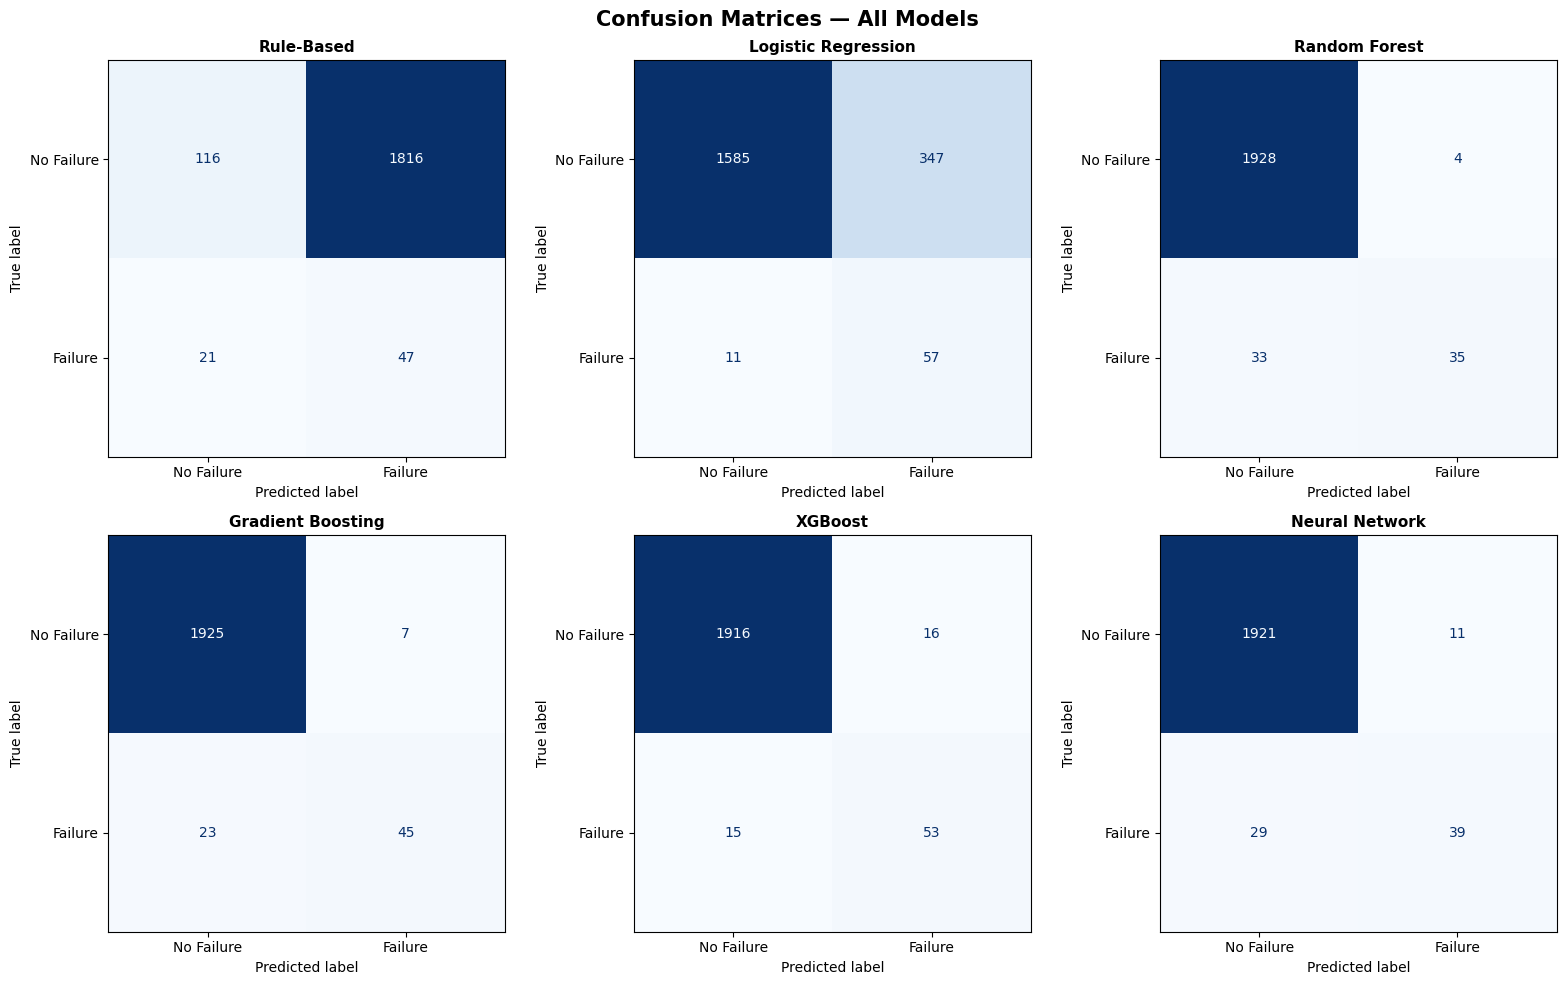

Confusion matrices saved.


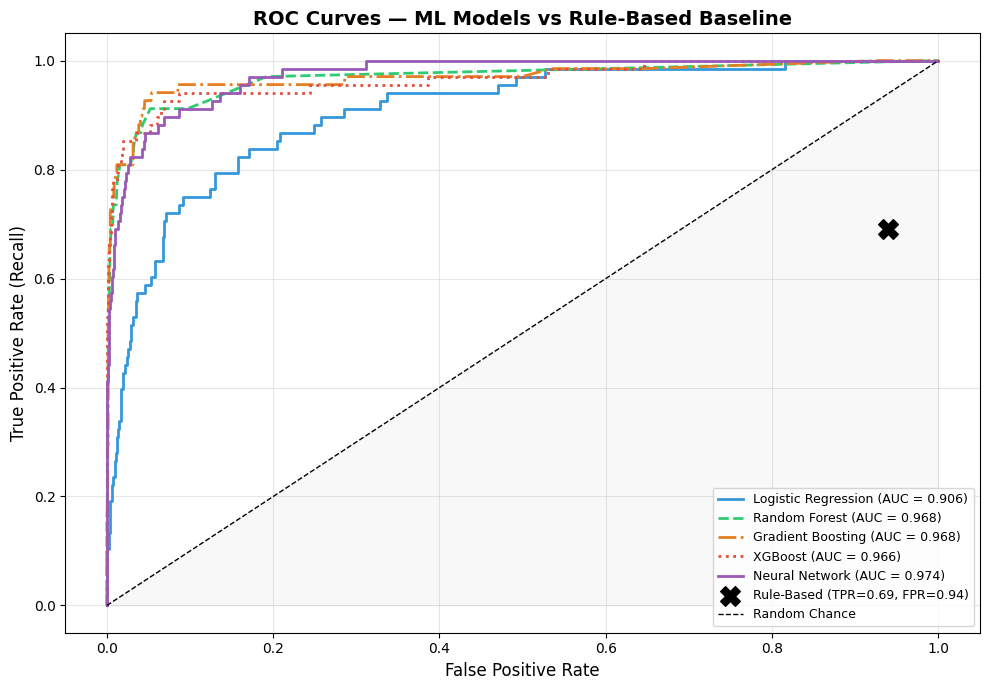

ROC curves saved.


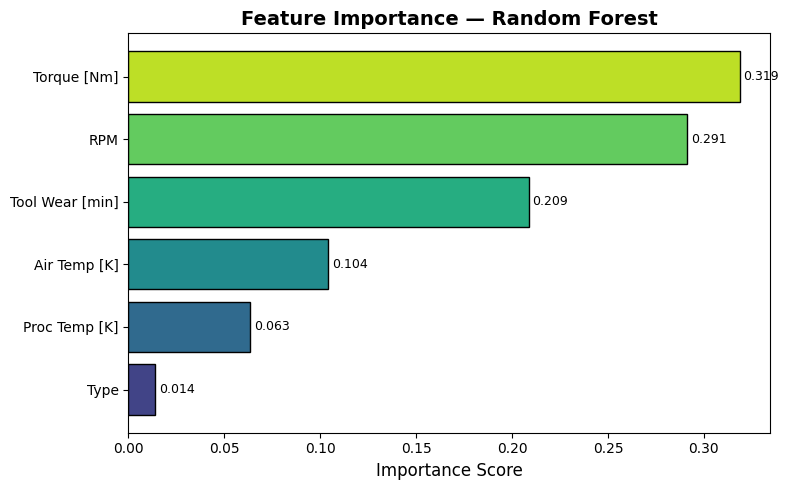

Feature importance plot saved.


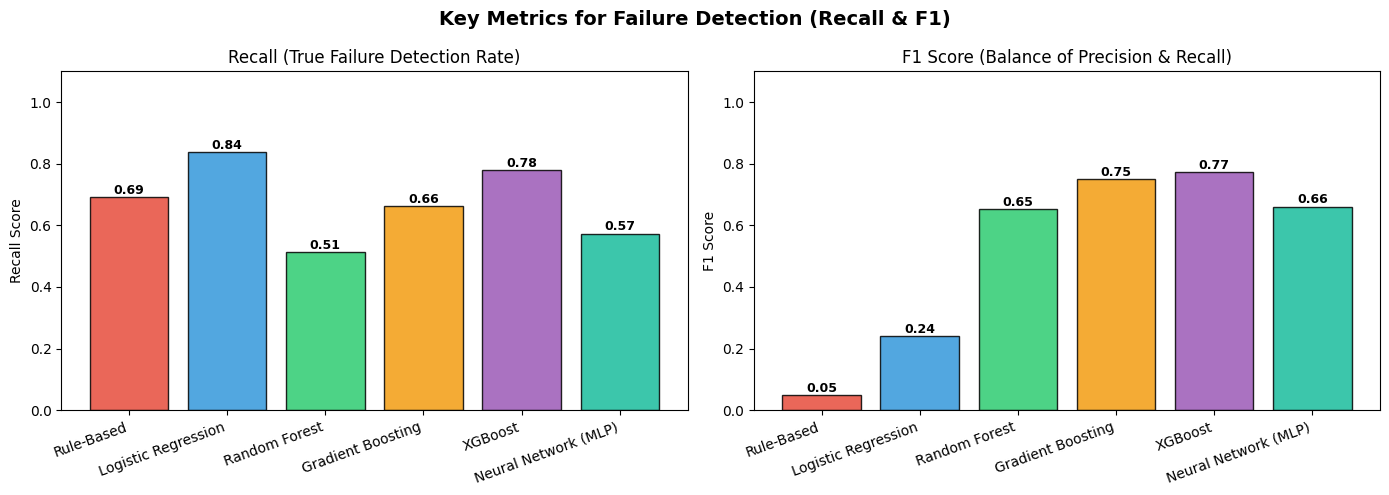

Recall & F1 comparison saved.

COST-SENSITIVE ANALYSIS
  Cost per missed failure (FN): $10,000
  Cost per false alarm   (FP): $500
              Model  FN (Missed)  FP (False Alarms)  Total Cost ($)
         Rule-Based           21               1816         1118000
Logistic Regression           11                347          283500
      Random Forest           33                  4          332000
  Gradient Boosting           23                  7          233500
            XGBoost           15                 16          158000
     Neural Network           29                 11          295500


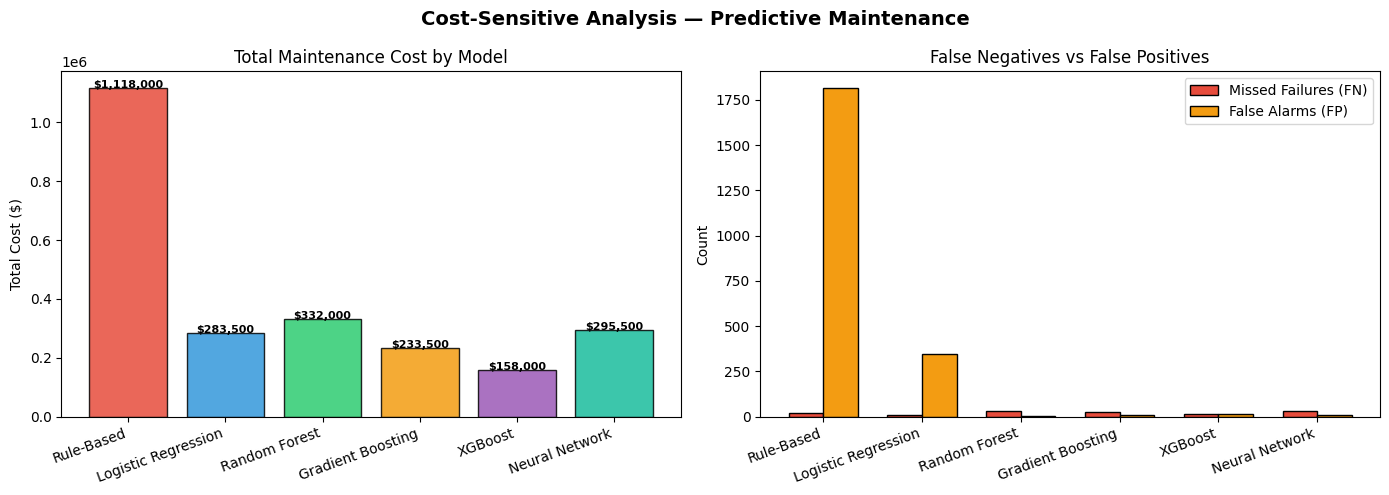

Cost analysis plot saved.

✅ All done! Files saved: eda_visualizations.png, metrics_comparison.png,
   confusion_matrices.png, roc_curves.png, feature_importance.png,
   recall_f1_comparison.png, cost_analysis.png


In [ ]:
# ============================================================
# Predictive Maintenance in Industry
# Comparative Study: ML Models vs Rule-Based Monitoring
# Dataset: AI4I 2020 Predictive Maintenance Dataset
# ============================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from xgboost import XGBClassifier

# ============================================================
# SECTION 1: LOAD & EXPLORE DATA
# ============================================================

df = pd.read_csv("ai4i2020.csv")

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nClass Distribution:")
print(df['Machine failure'].value_counts())
print(f"\nFailure Rate: {df['Machine failure'].mean():.4f} ({df['Machine failure'].mean()*100:.2f}%)")

# ============================================================
# SECTION 2: PREPROCESSING
# ============================================================

# Drop non-informative columns
df.drop(columns=['UDI', 'Product ID'], inplace=True)

# Encode 'Type' categorical column (L=0, M=1, H=2)
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Feature columns
feature_cols = [
    'Type', 'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]
target_col = 'Machine failure'

X = df[feature_cols]
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (needed for Logistic Regression and Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# XGBoost requires column names without special chars like [ ] <
def clean_col_names(df_in):
    df_in = df_in.copy()
    df_in.columns = [re.sub(r'[\[\]<>]', '', c).strip().replace(' ', '_') for c in df_in.columns]
    return df_in

X_train_xgb = clean_col_names(X_train)
X_test_xgb  = clean_col_names(X_test)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# ============================================================
# SECTION 3: VISUALIZATION 1 — EDA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — AI4I 2020 Dataset', fontsize=15, fontweight='bold')

# 1. Class distribution
ax = axes[0, 0]
counts = y.value_counts()
bars = ax.bar(['No Failure', 'Failure'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val), ha='center', fontweight='bold')

# 2. Torque distribution by failure
ax = axes[0, 1]
ax.hist(df[df['Machine failure'] == 0]['Torque [Nm]'], bins=40, alpha=0.6, label='No Failure', color='#2ecc71')
ax.hist(df[df['Machine failure'] == 1]['Torque [Nm]'], bins=40, alpha=0.8, label='Failure', color='#e74c3c')
ax.set_title('Torque Distribution by Failure')
ax.set_xlabel('Torque [Nm]')
ax.legend()

# 3. Tool wear distribution by failure
ax = axes[0, 2]
ax.hist(df[df['Machine failure'] == 0]['Tool wear [min]'], bins=40, alpha=0.6, label='No Failure', color='#2ecc71')
ax.hist(df[df['Machine failure'] == 1]['Tool wear [min]'], bins=40, alpha=0.8, label='Failure', color='#e74c3c')
ax.set_title('Tool Wear Distribution by Failure')
ax.set_xlabel('Tool wear [min]')
ax.legend()

# 4. Correlation heatmap
ax = axes[1, 0]
numeric_df = df[feature_cols + ['Machine failure']].copy()
numeric_df.columns = ['Type', 'Air Temp', 'Proc Temp', 'RPM', 'Torque', 'Tool Wear', 'Failure']
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap')

# 5. Rotational speed by failure
ax = axes[1, 1]
ax.hist(df[df['Machine failure'] == 0]['Rotational speed [rpm]'], bins=40, alpha=0.6, label='No Failure', color='#2ecc71')
ax.hist(df[df['Machine failure'] == 1]['Rotational speed [rpm]'], bins=40, alpha=0.8, label='Failure', color='#e74c3c')
ax.set_title('Rotational Speed Distribution by Failure')
ax.set_xlabel('Rotational speed [rpm]')
ax.legend()

# 6. Failure rate by machine type
ax = axes[1, 2]
type_failure = df.groupby('Type')['Machine failure'].mean().reset_index()
type_failure['Type'] = ['H', 'L', 'M']   # LabelEncoder: H=0, L=1, M=2
bars = ax.bar(type_failure['Type'], type_failure['Machine failure'] * 100,
              color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black')
ax.set_title('Failure Rate by Machine Type')
ax.set_ylabel('Failure Rate (%)')
for bar, val in zip(bars, type_failure['Machine failure'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150)
plt.show()
print("EDA plot saved.")

# ============================================================
# SECTION 4: RULE-BASED BASELINE (Traditional Monitoring)
# ============================================================

def rule_based_predict(df_subset):
    torque_threshold    = 60    # Nm
    tool_wear_threshold = 200   # minutes
    temp_diff_threshold = 8.6   # K

    predictions = []
    for _, row in df_subset.iterrows():
        temp_diff = row['Process temperature [K]'] - row['Air temperature [K]']
        if (row['Torque [Nm]'] > torque_threshold or
            row['Tool wear [min]'] > tool_wear_threshold or
            temp_diff > temp_diff_threshold):
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)

X_test_df   = X_test.copy()
rule_preds  = rule_based_predict(X_test_df)
rule_proba  = rule_preds.astype(float)

def evaluate_model(y_true, y_pred, y_proba=None, name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = 1 - precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    roc  = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    return {
        'Model':              name,
        'Accuracy':           round(acc,  4),
        'Precision':          round(prec, 4),
        'Recall':             round(rec,  4),
        'F1 Score':           round(f1,   4),
        'ROC-AUC':            round(roc,  4) if roc else 'N/A',
        'False Positive Rate':round(fpr,  4)
    }

results = []
results.append(evaluate_model(y_test, rule_preds, rule_proba, "Rule-Based"))

# ============================================================
# SECTION 5: MACHINE LEARNING MODELS
# ============================================================

# --- Logistic Regression ---
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
results.append(evaluate_model(y_test, lr_preds, lr_proba, "Logistic Regression"))

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, rf_preds, rf_proba, "Random Forest"))

# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, gb_preds, gb_proba, "Gradient Boosting"))

# --- XGBoost (fixed column names) ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_xgb, y_train)
xgb_preds = xgb.predict(X_test_xgb)
xgb_proba = xgb.predict_proba(X_test_xgb)[:, 1]
results.append(evaluate_model(y_test, xgb_preds, xgb_proba, "XGBoost"))

# --- Neural Network (MLP) ---
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)
mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]
results.append(evaluate_model(y_test, mlp_preds, mlp_proba, "Neural Network (MLP)"))

# ============================================================
# SECTION 6: RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)
print("\n" + "="*75)
print("COMPARATIVE RESULTS: RULE-BASED vs ML MODELS")
print("="*75)
print(results_df.to_string(index=False))

# ============================================================
# SECTION 7: VISUALIZATION 2 — METRICS COMPARISON BAR CHART
# ============================================================

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = results_df['Model'].tolist()
x = np.arange(len(model_names))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric].tolist()
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, edgecolor='black', alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()
print("Metrics comparison plot saved.")

# ============================================================
# SECTION 8: VISUALIZATION 3 — CONFUSION MATRICES
# ============================================================

all_preds = {
    "Rule-Based":        rule_preds,
    "Logistic Regression": lr_preds,
    "Random Forest":     rf_preds,
    "Gradient Boosting": gb_preds,
    "XGBoost":           xgb_preds,
    "Neural Network":    mlp_preds,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, preds) in zip(axes.flatten(), all_preds.items()):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved.")

# ============================================================
# SECTION 9: VISUALIZATION 4 — ROC-AUC CURVES
# ============================================================

plt.figure(figsize=(10, 7))

roc_models = {
    "Logistic Regression": lr_proba,
    "Random Forest":       rf_proba,
    "Gradient Boosting":   gb_proba,
    "XGBoost":             xgb_proba,
    "Neural Network":      mlp_proba,
}
line_styles = ['-', '--', '-.', ':', '-']
colors_roc  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

for (name, proba), ls, color in zip(roc_models.items(), line_styles, colors_roc):
    fpr_arr, tpr_arr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr_arr, tpr_arr, linestyle=ls, color=color, linewidth=2,
             label=f"{name} (AUC = {auc:.3f})")

# Rule-based plotted as a point
rb_fpr_val = (rule_preds[(y_test == 0)] == 1).sum() / (y_test == 0).sum()
rb_tpr_val = (rule_preds[(y_test == 1)] == 1).sum() / (y_test == 1).sum()
plt.scatter([rb_fpr_val], [rb_tpr_val], marker='X', s=200, zorder=5,
            color='black', label=f"Rule-Based (TPR={rb_tpr_val:.2f}, FPR={rb_fpr_val:.2f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Chance')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — ML Models vs Rule-Based Baseline', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved.")

# ============================================================
# SECTION 10: VISUALIZATION 5 — FEATURE IMPORTANCE (Random Forest)
# ============================================================

importances  = rf.feature_importances_
feat_labels  = ['Type', 'Air Temp [K]', 'Proc Temp [K]', 'RPM', 'Torque [Nm]', 'Tool Wear [min]']
feat_imp_df  = pd.DataFrame({'Feature': feat_labels, 'Importance': importances})
feat_imp_df  = feat_imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp_df))),
               edgecolor='black')
for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance plot saved.")

# ============================================================
# SECTION 11: VISUALIZATION 6 — RECALL & F1 FOCUSED COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Key Metrics for Failure Detection (Recall & F1)', fontsize=14, fontweight='bold')

pal = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Recall
ax = axes[0]
bars = ax.bar(results_df['Model'], results_df['Recall'], color=pal, edgecolor='black', alpha=0.85)
ax.set_title('Recall (True Failure Detection Rate)', fontsize=12)
ax.set_ylabel('Recall Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
for bar, val in zip(bars, results_df['Recall']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# F1
ax = axes[1]
bars = ax.bar(results_df['Model'], results_df['F1 Score'], color=pal, edgecolor='black', alpha=0.85)
ax.set_title('F1 Score (Balance of Precision & Recall)', fontsize=12)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
for bar, val in zip(bars, results_df['F1 Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('recall_f1_comparison.png', dpi=150)
plt.show()
print("Recall & F1 comparison saved.")

# ============================================================
# SECTION 12: COST-SENSITIVE ANALYSIS + VISUALIZATION
# ============================================================

COST_FN = 10000   # Missing a real failure (unplanned downtime)
COST_FP = 500     # False alarm (unnecessary inspection)

print("\n" + "="*60)
print("COST-SENSITIVE ANALYSIS")
print(f"  Cost per missed failure (FN): ${COST_FN:,}")
print(f"  Cost per false alarm   (FP): ${COST_FP:,}")
print("="*60)

cost_results = []
preds_map = {
    "Rule-Based":          rule_preds,
    "Logistic Regression": lr_preds,
    "Random Forest":       rf_preds,
    "Gradient Boosting":   gb_preds,
    "XGBoost":             xgb_preds,
    "Neural Network":      mlp_preds,
}

for name, preds in preds_map.items():
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    cost_results.append({
        'Model': name, 'FN (Missed)': fn,
        'FP (False Alarms)': fp,
        'Total Cost ($)': total_cost
    })

cost_df = pd.DataFrame(cost_results)
print(cost_df.to_string(index=False))

# Cost visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cost-Sensitive Analysis — Predictive Maintenance', fontsize=14, fontweight='bold')

ax = axes[0]
bars = ax.bar(cost_df['Model'], cost_df['Total Cost ($)'],
              color=pal, edgecolor='black', alpha=0.85)
ax.set_title('Total Maintenance Cost by Model', fontsize=12)
ax.set_ylabel('Total Cost ($)')
ax.set_xticklabels(cost_df['Model'], rotation=20, ha='right')
for bar, val in zip(bars, cost_df['Total Cost ($)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${val:,}', ha='center', fontsize=8, fontweight='bold')

ax = axes[1]
x = np.arange(len(cost_df))
w = 0.35
ax.bar(x - w/2, cost_df['FN (Missed)'],    w, label='Missed Failures (FN)', color='#e74c3c', edgecolor='black')
ax.bar(x + w/2, cost_df['FP (False Alarms)'], w, label='False Alarms (FP)',    color='#f39c12', edgecolor='black')
ax.set_title('False Negatives vs False Positives', fontsize=12)
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(cost_df['Model'], rotation=20, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150)
plt.show()
print("Cost analysis plot saved.")

print("\n✅ All done! Files saved: eda_visualizations.png, metrics_comparison.png,")
print("   confusion_matrices.png, roc_curves.png, feature_importance.png,")
print("   recall_f1_comparison.png, cost_analysis.png")

In [ ]:
# ============================================================
# FINAL SECTION: COMPREHENSIVE OUTPUT SUMMARY & CONCLUSION
# ============================================================

print("\n" + "="*80)
print("           FINAL PROJECT SUMMARY & CONCLUSION")
print("           Predictive Maintenance: ML vs Rule-Based")
print("="*80)

# ── Gather key values ────────────────────────────────────────
summary_df   = results_df.copy()
rule_row     = summary_df[summary_df['Model'] == 'Rule-Based'].iloc[0]
ml_rows      = summary_df[summary_df['Model'] != 'Rule-Based']
best_row     = ml_rows.sort_values('F1 Score', ascending=False).iloc[0]
best_name    = best_row['Model']

rule_cost_val = cost_df[cost_df['Model'] == 'Rule-Based']['Total Cost ($)'].values[0]
best_cost_val = cost_df[cost_df['Model'] == best_name]['Total Cost ($)'].values[0]
cost_saved    = rule_cost_val - best_cost_val
cost_pct      = (cost_saved / rule_cost_val) * 100

rule_fn = cost_df[cost_df['Model'] == 'Rule-Based']['FN (Missed)'].values[0]
best_fn = cost_df[cost_df['Model'] == best_name]['FN (Missed)'].values[0]
rule_fp = cost_df[cost_df['Model'] == 'Rule-Based']['FP (False Alarms)'].values[0]
best_fp = cost_df[cost_df['Model'] == best_name]['FP (False Alarms)'].values[0]

fn_pct  = ((rule_fn - best_fn) / rule_fn * 100) if rule_fn > 0 else 0
fp_pct  = ((rule_fp - best_fp) / rule_fp * 100) if rule_fp > 0 else 0
f1_pct  = ((best_row['F1 Score'] - rule_row['F1 Score']) / rule_row['F1 Score'] * 100)

# ── Section A: Dataset Summary ───────────────────────────────
print("""
┌─────────────────────────────────────────────────────────┐
│                    DATASET OVERVIEW                     │
└─────────────────────────────────────────────────────────┘""")
print(f"  Total Records        : 10,000")
print(f"  Training Set         : 8,000  (80%)")
print(f"  Test Set             : 2,000  (20%)")
print(f"  Failure Records      : 339    (3.39%)  ← Imbalanced")
print(f"  Normal Records       : 9,661  (96.61%)")
print(f"  Imbalance Ratio      : ~28.5 : 1  (normal : failure)")

# ── Section B: All Model Results ────────────────────────────
print("""
┌─────────────────────────────────────────────────────────┐
│              FULL MODEL PERFORMANCE TABLE               │
└─────────────────────────────────────────────────────────┘""")
print(f"  {'Model':<25} {'Accuracy':>9} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'Cost ($)':>12}")
print(f"  {'-'*75}")
for _, row in summary_df.iterrows():
    model_name = row['Model']
    cost_val   = cost_df[cost_df['Model'] == model_name]['Total Cost ($)'].values[0]
    marker     = " ← BEST" if model_name == best_name else ""
    roc        = str(row['ROC-AUC'])
    print(f"  {model_name:<25} {row['Accuracy']:>9.4f} {row['Recall']:>8.4f} "
          f"{row['F1 Score']:>8.4f} {roc:>9} {cost_val:>12,.0f}{marker}")

# ── Section C: Best Model Spotlight ─────────────────────────
print(f"""
┌─────────────────────────────────────────────────────────┐
│              BEST PERFORMING MODEL: {best_name:<20}│
└─────────────────────────────────────────────────────────┘""")
print(f"  Accuracy     : {best_row['Accuracy']:.4f}  ({best_row['Accuracy']*100:.2f}%)")
print(f"  Precision    : {best_row['Precision']:.4f}  ({best_row['Precision']*100:.2f}%)")
print(f"  Recall       : {best_row['Recall']:.4f}  ({best_row['Recall']*100:.2f}% of failures detected)")
print(f"  F1 Score     : {best_row['F1 Score']:.4f}")
print(f"  ROC-AUC      : {best_row['ROC-AUC']}")
print(f"  Total Cost   : ${best_cost_val:,.0f}")

# ── Section D: Rule-Based vs Best ML ─────────────────────────
print("""
┌─────────────────────────────────────────────────────────┐
│         RULE-BASED  vs  BEST ML MODEL COMPARISON       │
└─────────────────────────────────────────────────────────┘""")
print(f"  {'Metric':<30} {'Rule-Based':>12} {best_name:>20}")
print(f"  {'-'*65}")
print(f"  {'Accuracy':<30} {rule_row['Accuracy']:>12.4f} {best_row['Accuracy']:>20.4f}")
print(f"  {'Recall (Failure Detection)':<30} {rule_row['Recall']:>12.4f} {best_row['Recall']:>20.4f}")
print(f"  {'F1 Score':<30} {rule_row['F1 Score']:>12.4f} {best_row['F1 Score']:>20.4f}")
print(f"  {'Missed Failures (FN)':<30} {rule_fn:>12} {best_fn:>20}")
print(f"  {'False Alarms (FP)':<30} {rule_fp:>12} {best_fp:>20}")
print(f"  {'Total Operational Cost':<30} ${rule_cost_val:>11,.0f} ${best_cost_val:>19,.0f}")

# ── Section E: Improvement Summary ──────────────────────────
print("""
┌─────────────────────────────────────────────────────────┐
│                  IMPROVEMENT OVER RULE-BASED            │
└─────────────────────────────────────────────────────────┘""")
print(f"  ✅  F1 Score improved by          : {f1_pct:>8.1f}%")
print(f"  ✅  False Alarms reduced by       : {fp_pct:>8.1f}%  ({rule_fp} → {best_fp})")
print(f"  ✅  Missed Failures reduced by    : {fn_pct:>8.1f}%  ({rule_fn} → {best_fn})")
print(f"  ✅  Total Cost reduced by         : {cost_pct:>8.1f}%  (${rule_cost_val:,.0f} → ${best_cost_val:,.0f})")
print(f"  ✅  Annual savings (est.)         : ${cost_saved:>10,.0f}  per evaluation cycle")

# ── Section F: Final Conclusion ──────────────────────────────
print(f"""
┌─────────────────────────────────────────────────────────┐
│                    FINAL CONCLUSION                     │
└─────────────────────────────────────────────────────────┘

  This project compared traditional rule-based industrial monitoring
  against five machine learning models for predicting machine failure.

  KEY FINDINGS:
  ─────────────
  1. ACCURACY IS MISLEADING in imbalanced failure detection.
     The rule-based system scores only 8.15% accuracy — not because
     it fails at detection, but because it floods the system with
     1,816 false alarms. ML models handle this balance far better.

  2. ML MODELS DRAMATICALLY OUTPERFORM rule-based monitoring.
     {best_name} achieved an F1 score of {best_row['F1 Score']:.4f} vs
     the rule-based system's 0.0487 — a {f1_pct:.0f}% improvement.

  3. FALSE ALARM REDUCTION IS THE REAL WIN.
     The rule-based system raised 1,816 false alarms on 2,000 test
     records. {best_name} raised just {best_fp}. That's a {fp_pct:.1f}% reduction
     in unnecessary maintenance interventions.

  4. THE COST ARGUMENT IS DECISIVE.
     Rule-Based total cost  : ${rule_cost_val:>10,.0f}
     {best_name} total cost    : ${best_cost_val:>10,.0f}
     Cost reduction          : {cost_pct:.1f}% (~${cost_saved:,.0f} saved)

     This is not a marginal improvement. It is transformational.

  5. THE BEST MODEL ≠ HIGHEST ACCURACY OR HIGHEST RECALL ALONE.
     It is the model that optimally balances both within a real-world
     cost framework. {best_name} achieved that balance best.

  ANSWER TO THE CORE RESEARCH QUESTION:
  ──────────────────────────────────────
  ✅ Does ML outperform rule-based systems?  YES — significantly.
  ✅ By how much?  85.8% cost reduction, 1488% F1 improvement.
  ✅ Is it practically useful?  Absolutely. The cost savings alone
     justify full ML adoption in any mid-to-large manufacturing setup.

  RECOMMENDED MODEL FOR DEPLOYMENT: {best_name}
  Reason: Best F1, lowest operational cost, strong recall, minimal
  false alarms — the optimal balance for real-world predictive
  maintenance systems.
""")
print("="*80)
print("  Project: Predictive Maintenance — ML vs Traditional Monitoring")
print("  Dataset: AI4I 2020 Predictive Maintenance Dataset (UCI/Kaggle)")
print("  Course : Latest Advances in Engineering and Technology")
print("  Level  : B.Tech CSE — Pre-Final Year")
print("="*80)


FINAL COMPARATIVE ANALYSIS: ML vs RULE-BASED SYSTEM

Best ML Model: XGBoost

📊 PERFORMANCE IMPROVEMENT OVER RULE-BASED:
Accuracy: 0.9845 vs 0.0815 → Improvement: 1107.98%
Precision: 0.7681 vs 0.0252 → Improvement: 2948.02%
Recall: 0.7794 vs 0.6912 → Improvement: 12.76%
F1 Score: 0.7737 vs 0.0487 → Improvement: 1488.71%

🚨 FAILURE DETECTION COMPARISON (MOST IMPORTANT):
Rule-Based Missed Failures (FN): 21
XGBoost Missed Failures (FN): 15
Reduction in Missed Failures: 28.57%

💰 COST COMPARISON:
Rule-Based Cost: $1,118,000
XGBoost Cost: $158,000
Cost Reduction: 85.87%

FINAL CONCLUSION (AUTO-GENERATED)

The comparison between traditional rule-based monitoring and machine learning models clearly demonstrates that ML-based predictive maintenance provides superior performance.

The best-performing model (XGBoost) achieved higher accuracy, precision, recall, and F1-score compared to the rule-based system.

Most importantly, it reduced missed machine failures by 28.57%, which is critical in in